---------------------------------------------------------------------------------------------------------------
# Correlation Analysis
---------------------------------------------------------------------------------------------------------------
## Content Log:
1. Import Libraries
2. Load Data
3. Correlation Heatmap
4. Combining all Datasets together for Heatmap
5. All Datasets Combined Heatmap
6. Key Observations
---------------------------------------------------------------------------------------------------------------

# 01. Import Libraries

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

# 02. Load Data

In [2]:
data_path = "../../data/raw_data"
datasets = {}
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_path, file), low_memory=False)
        df["Ticker"] = file.replace(".csv", "")
        datasets[file] = df

# 03. Correlation Heatmap

Correlation Matrix: ADANIENT_NS.csv


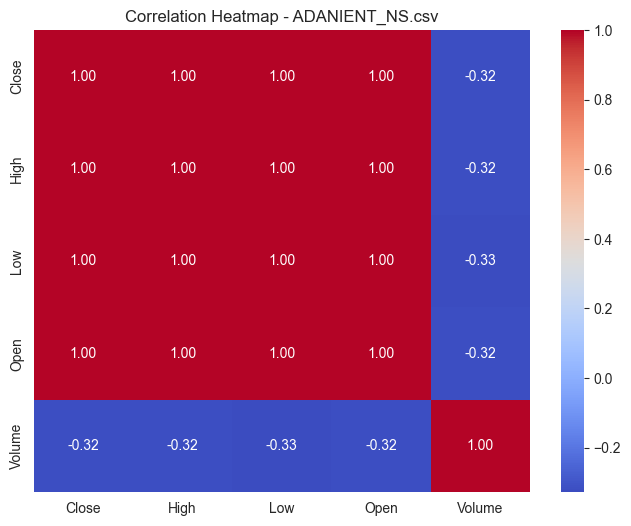

Correlation Matrix: ADANIPORTS_NS.csv


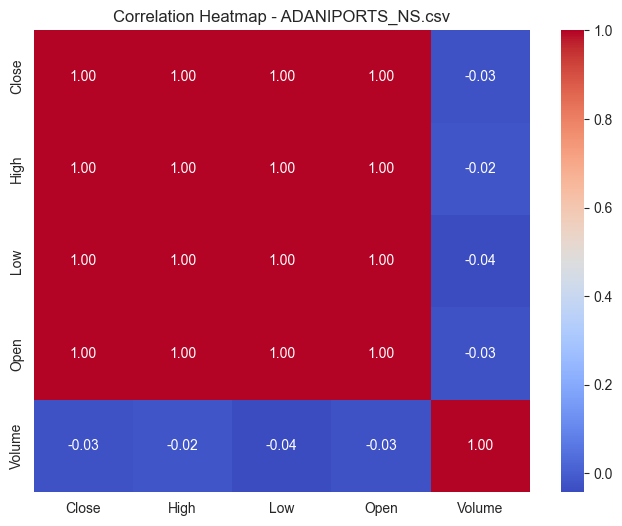

Correlation Matrix: ASIANPAINT_NS.csv


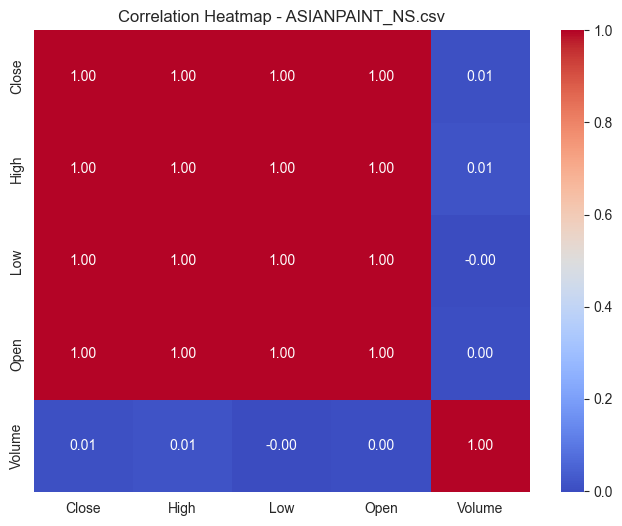

Correlation Matrix: AXISBANK_NS.csv


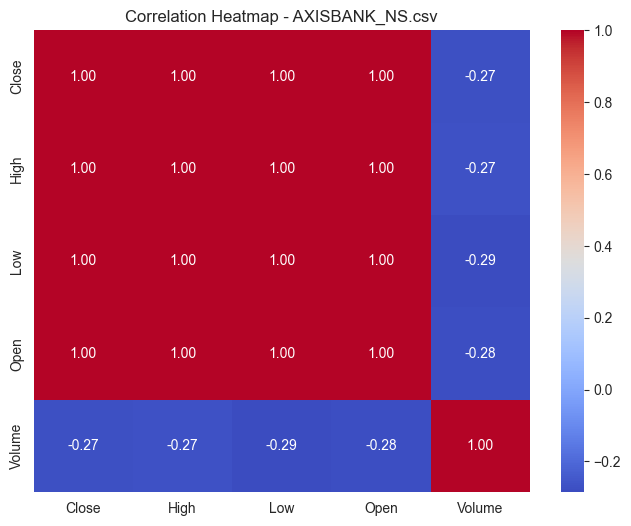

Correlation Matrix: BAJAJFINSV_NS.csv


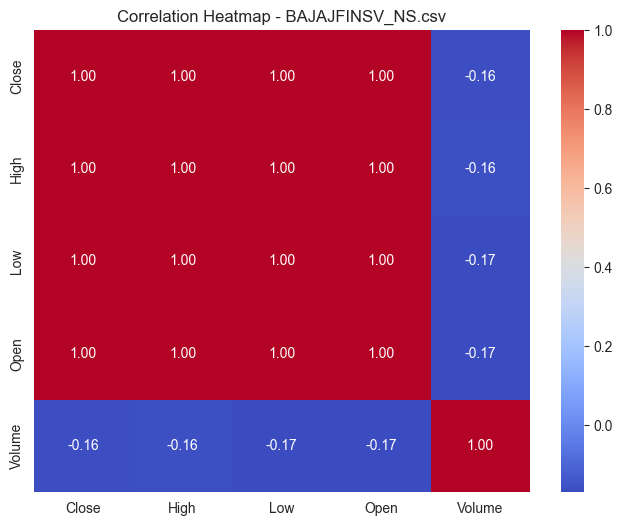

Correlation Matrix: BAJFINANCE_NS.csv


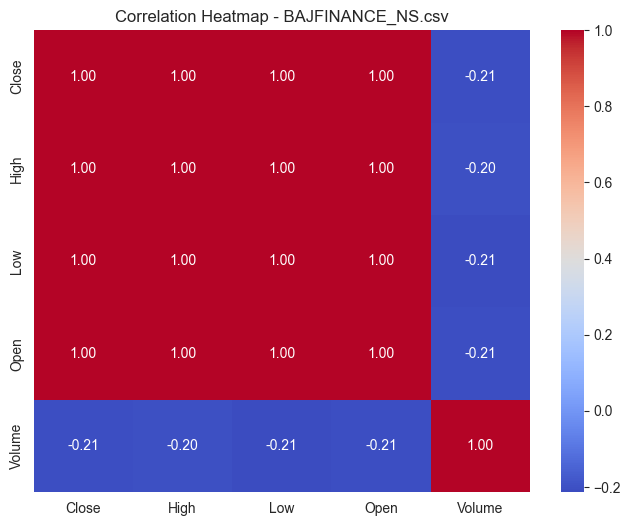

Correlation Matrix: BHARTIARTL_NS.csv


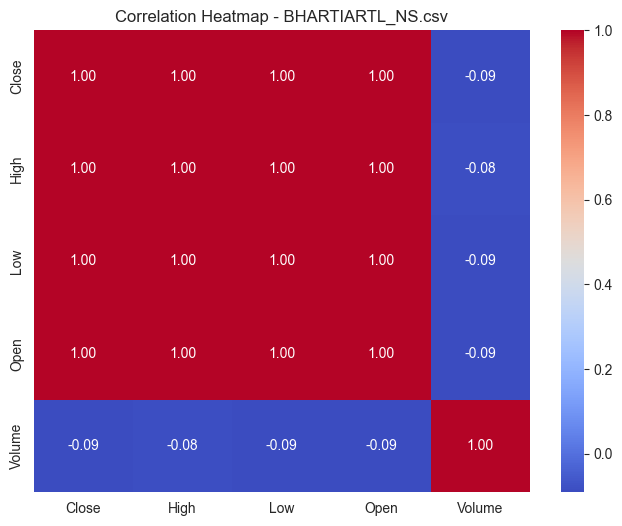

Correlation Matrix: DRREDDY_NS.csv


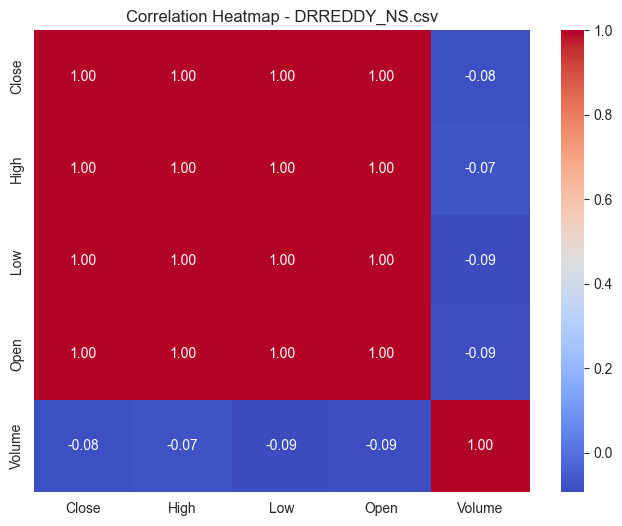

Correlation Matrix: EICHERMOT_NS.csv


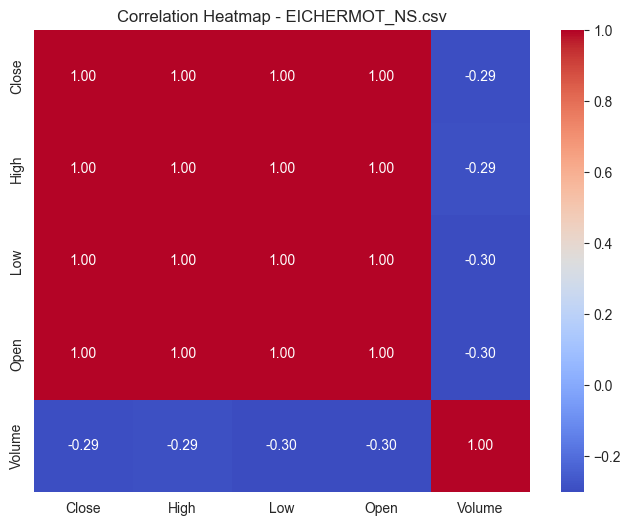

Correlation Matrix: HCLTECH_NS.csv


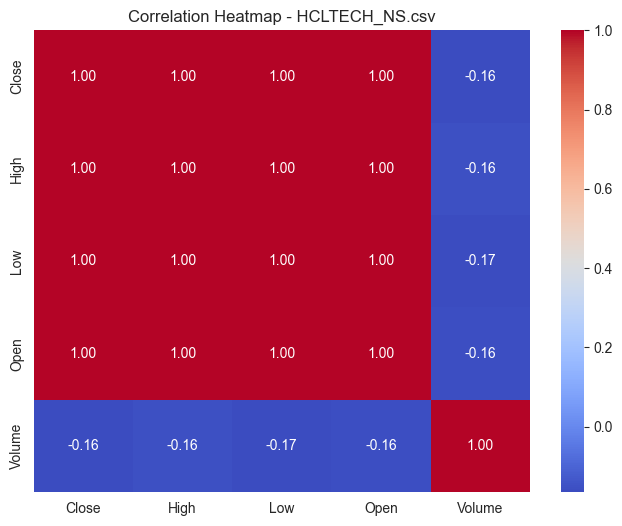

Correlation Matrix: HDFCBANK_NS.csv


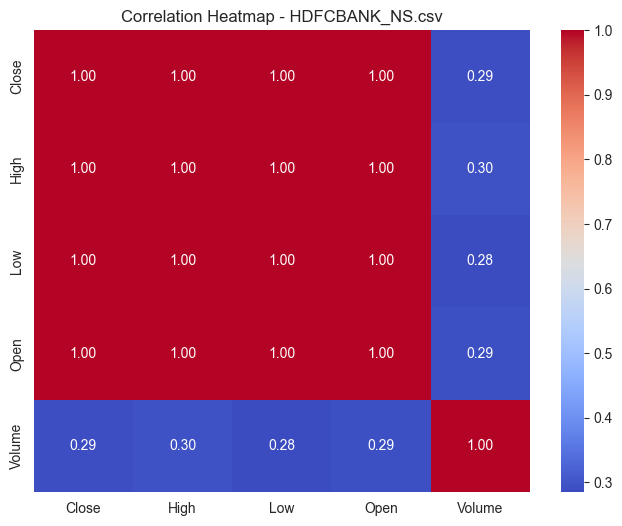

Correlation Matrix: HINDUNILVR_NS.csv


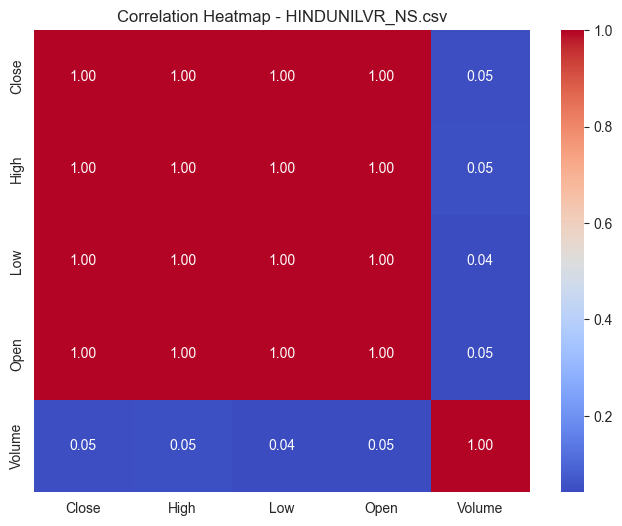

Correlation Matrix: ICICIBANK_NS.csv


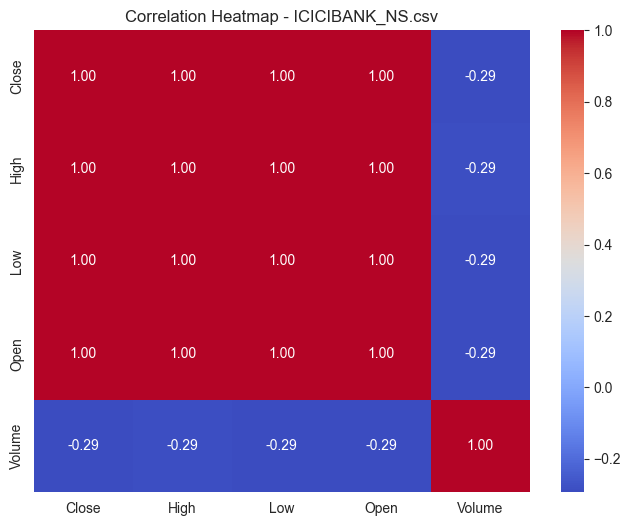

Correlation Matrix: INFY_NS.csv


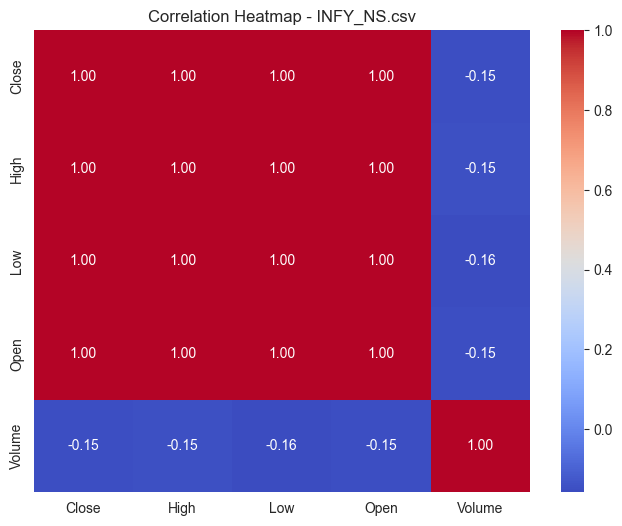

Correlation Matrix: ITC_NS.csv


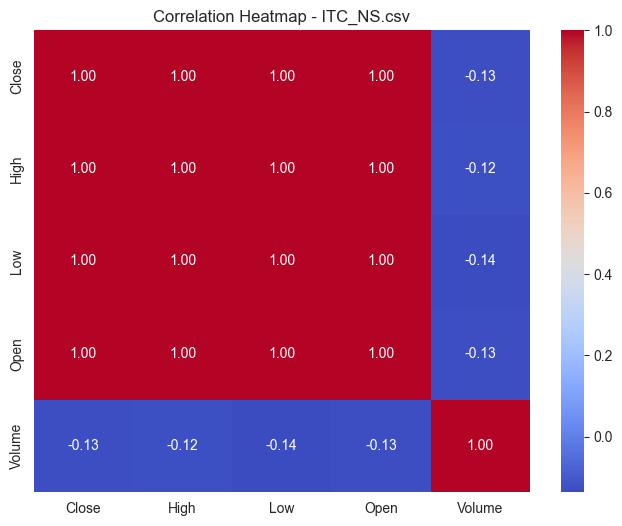

Correlation Matrix: KOTAKBANK_NS.csv


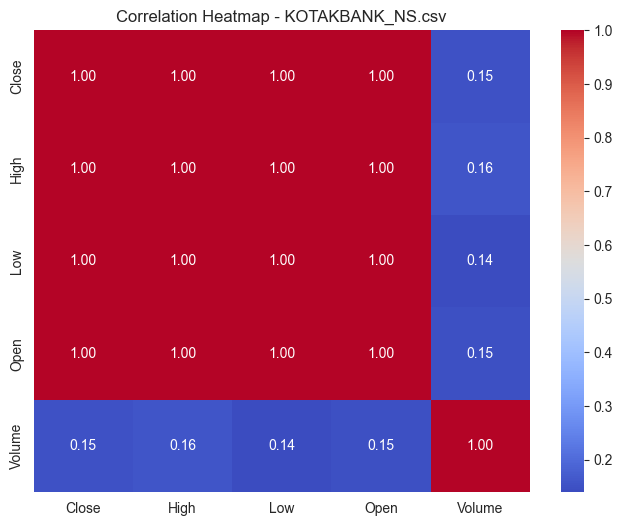

Correlation Matrix: LT_NS.csv


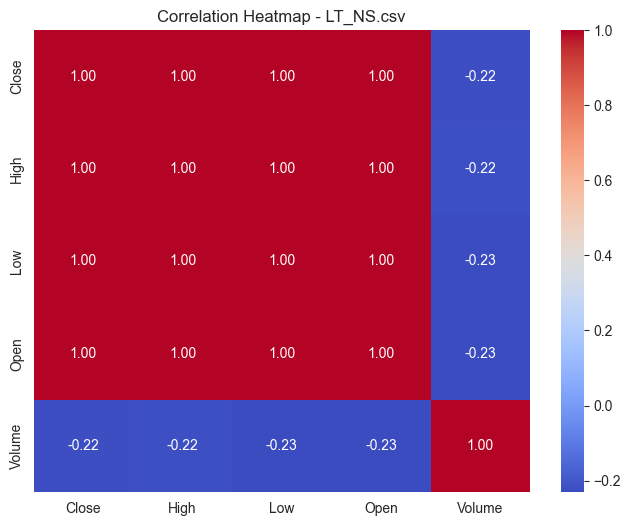

Correlation Matrix: MARUTI_NS.csv


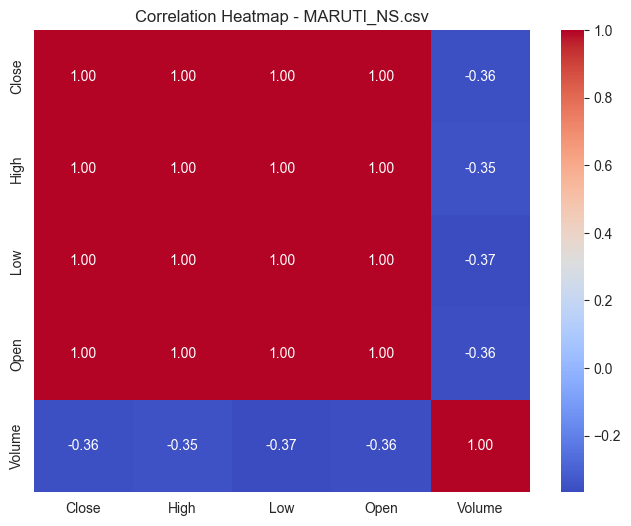

Correlation Matrix: NESTLEIND_NS.csv


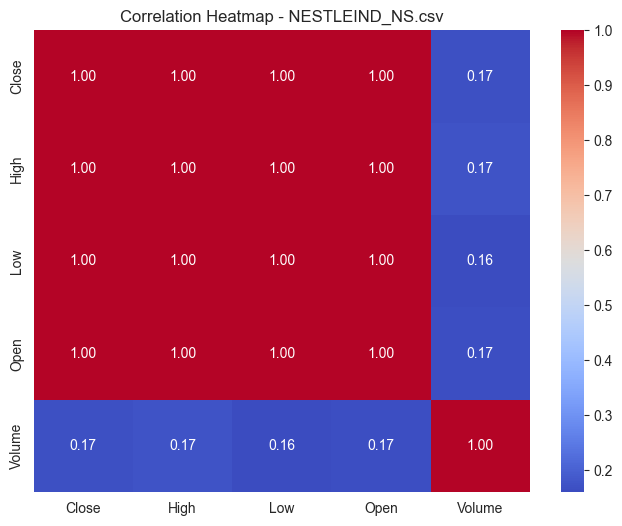

Correlation Matrix: NTPC_NS.csv


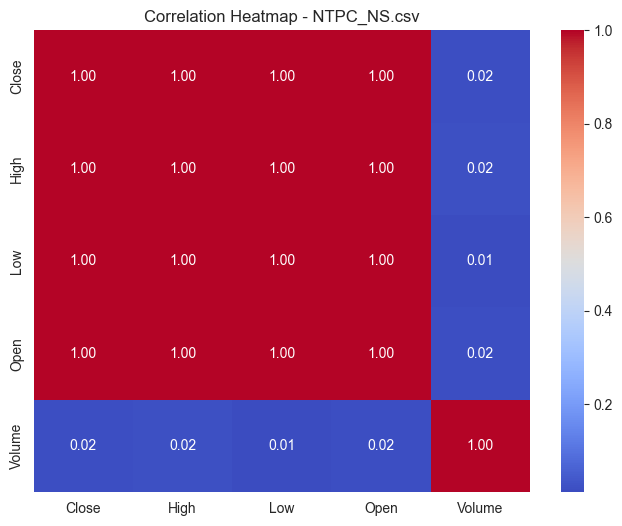

Correlation Matrix: ONGC_NS.csv


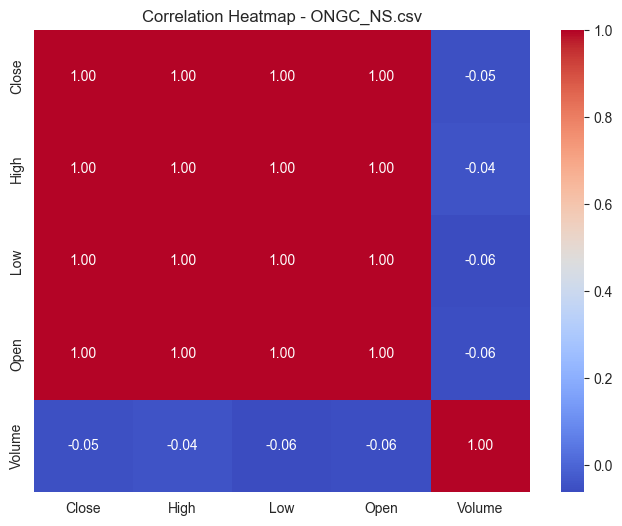

Correlation Matrix: POWERGRID_NS.csv


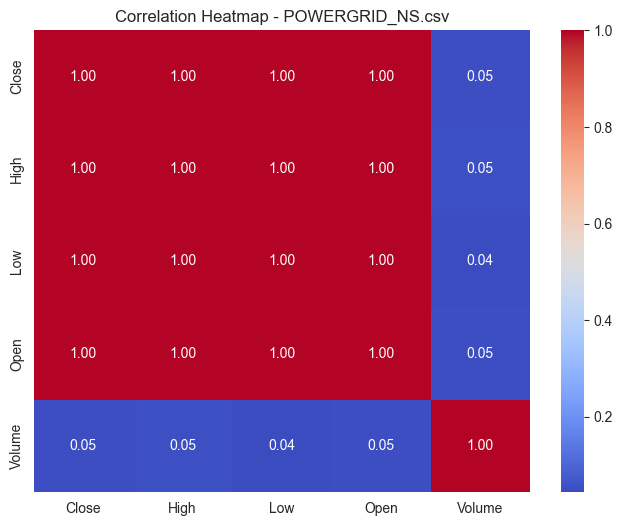

Correlation Matrix: RELIANCE_NS.csv


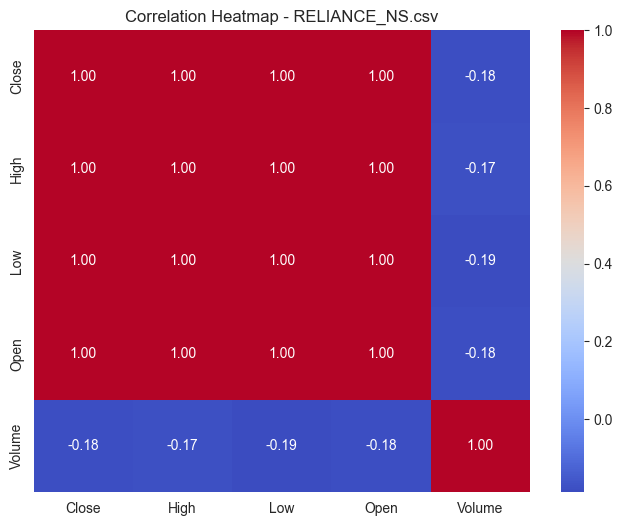

Correlation Matrix: SBIN_NS.csv


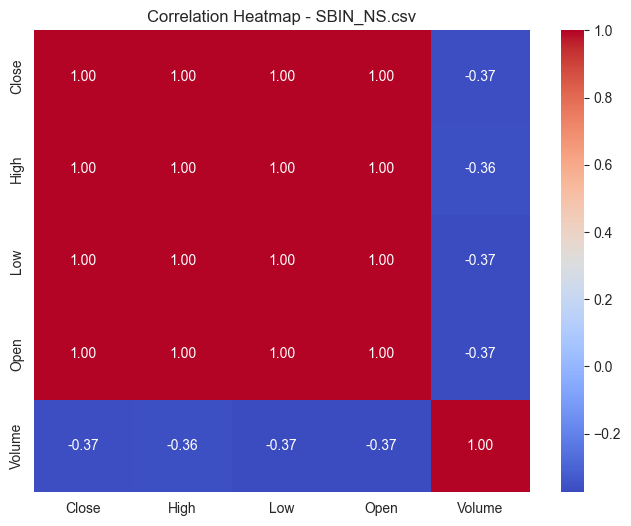

Correlation Matrix: SUNPHARMA_NS.csv


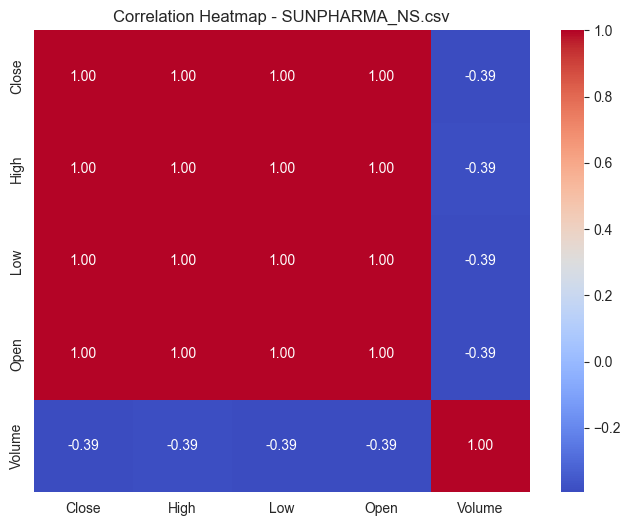

Correlation Matrix: TCS_NS.csv


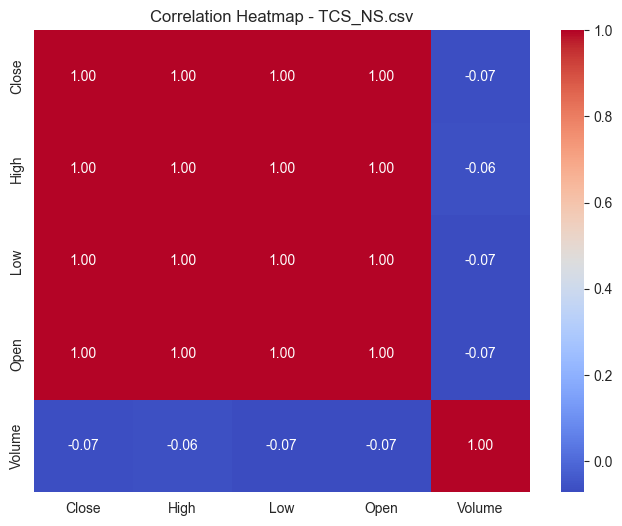

Correlation Matrix: TECHM_NS.csv


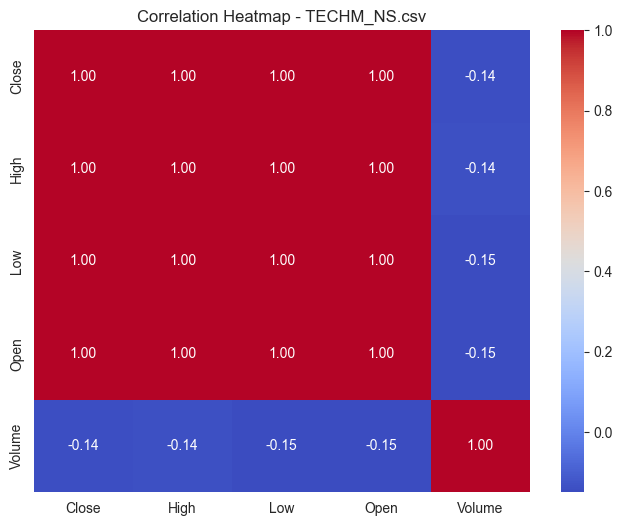

Correlation Matrix: TITAN_NS.csv


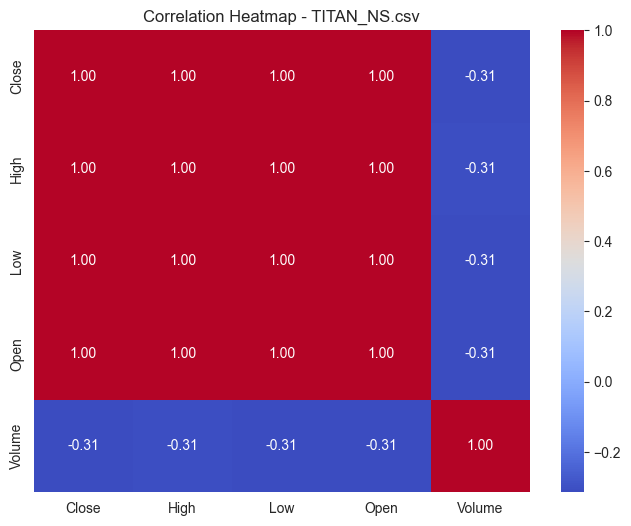

Correlation Matrix: ULTRACEMCO_NS.csv


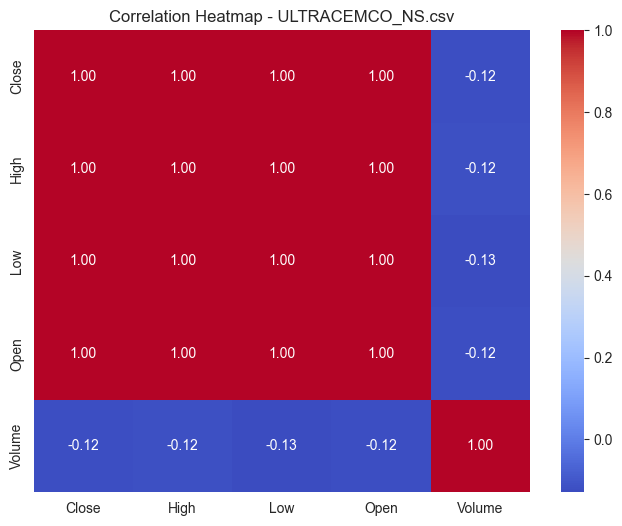

Correlation Matrix: WIPRO_NS.csv


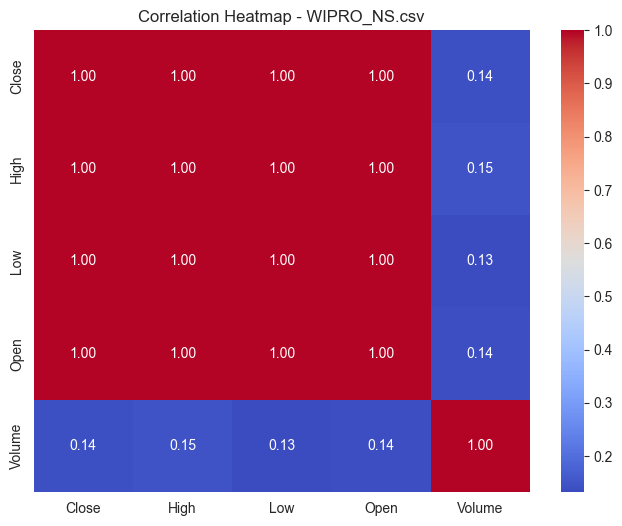

In [3]:
for name, df in datasets.items():
    print("="*60)
    print(f"Correlation Matrix: {name}")
    print("="*60)
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlation Heatmap - {name}")
    plt.show()

# 04. Combining all Datasets together for Heatmap

In [4]:
combined = pd.DataFrame()
for name, df in datasets.items():
    if "Date" in df.columns and "Close" in df.columns:
        temp = df[["Date", "Close"]].copy()
        temp.rename(columns={"Close": name}, inplace=True)
        if combined.empty:
            combined = temp
        else:
            combined = pd.merge(combined, temp, on="Date", how="outer")
combined.set_index("Date", inplace=True)
corr_matrix = combined.corr()

# 05. All Datasets Combined Heatmap

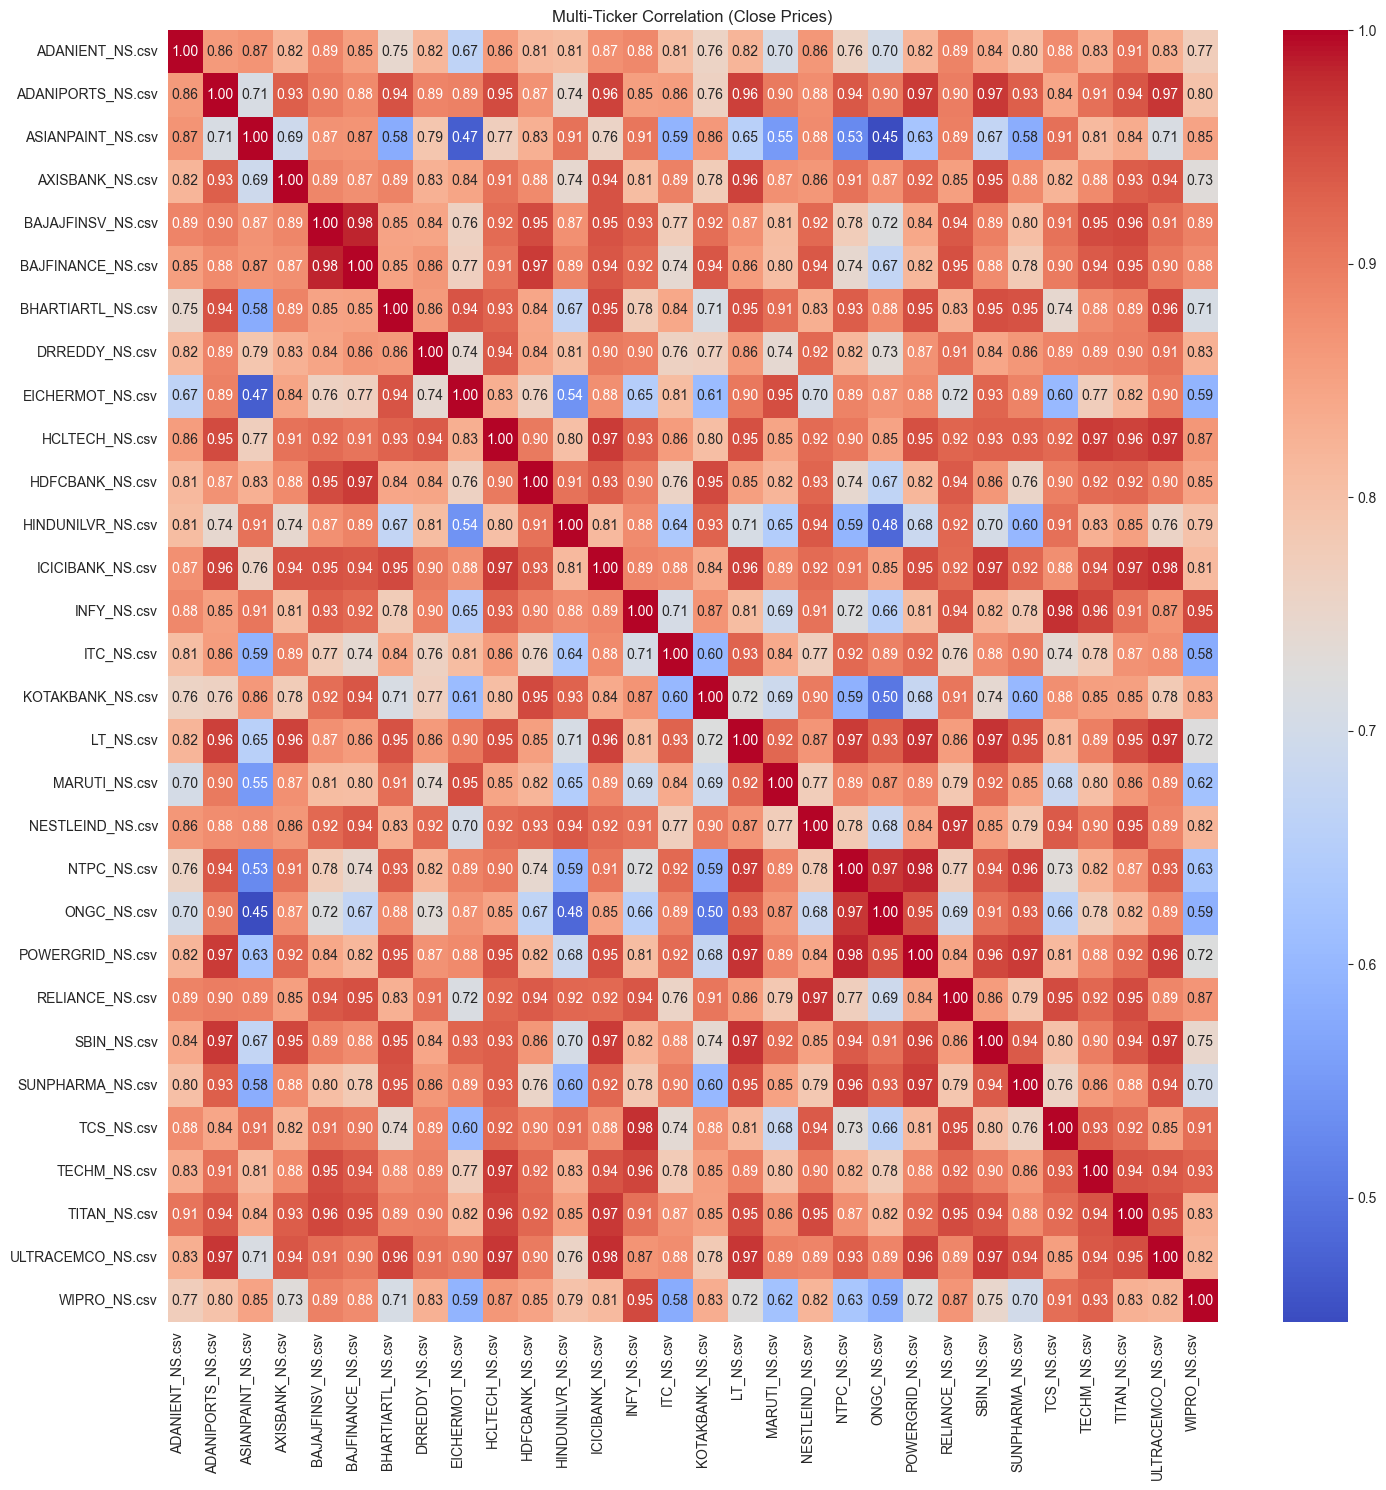

In [10]:
plt.figure(figsize=(15, 15))
ax = sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Multi-Ticker Correlation (Close Prices)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# 06. Key Observations
1. According to **Correlation Heatmap** all columns are **100% correlated with each other in a positive correlation; except the "Volumne" column of all individual dataset that shows the **Negative correlations** with all other 4 atributes. It means **Open, High, Low and close affects each other directly and perfectly in a positive manner but negavitely to Volume attribute**
2. Whenever **Open, High, Low and Close increased, Volume decreased**
3. The observations from the **All Datasets Combined Heatmap** will be found in: Advanced EDA report.